In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.calibration import calibration_curve
from sklearn.datasets import make_classification
from sklearn.metrics import brier_score_loss
from sklearn.model_selection import train_test_split, StratifiedKFold
from statsmodels.stats.contingency_tables import mcnemar
from torch.nn import CrossEntropyLoss
from torch.utils.data import DataLoader, TensorDataset, Subset
from torch.utils.tensorboard import SummaryWriter


2026-06-16 21:40:00.828467: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
writer = SummaryWriter(f"runs/training")

In [3]:
X, y = make_classification(n_samples=5000, n_features=20, random_state=42)
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.long)
X_train_val_cal, X_test, y_train_val_cal, y_test = train_test_split(X, y, stratify=y, test_size=0.2)

X_trainval, X_cal, y_trainval, y_cal = train_test_split(X_train_val_cal, y_train_val_cal, stratify=y_train_val_cal, test_size=0.2)
trainval_dataset = TensorDataset(X_trainval, y_trainval)

<BarContainer object of 2 artists>

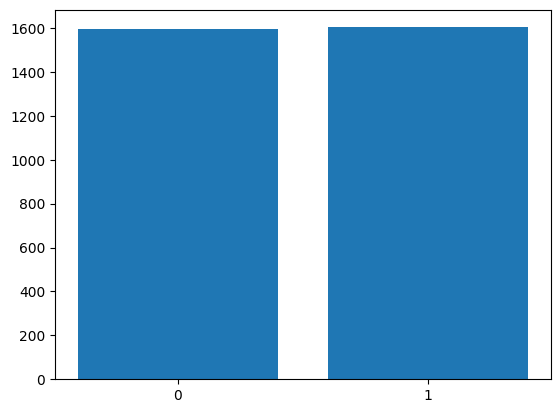

In [4]:
plt.bar(["0", "1"], [(y_trainval == 0).sum(), (y_trainval == 1).sum()])

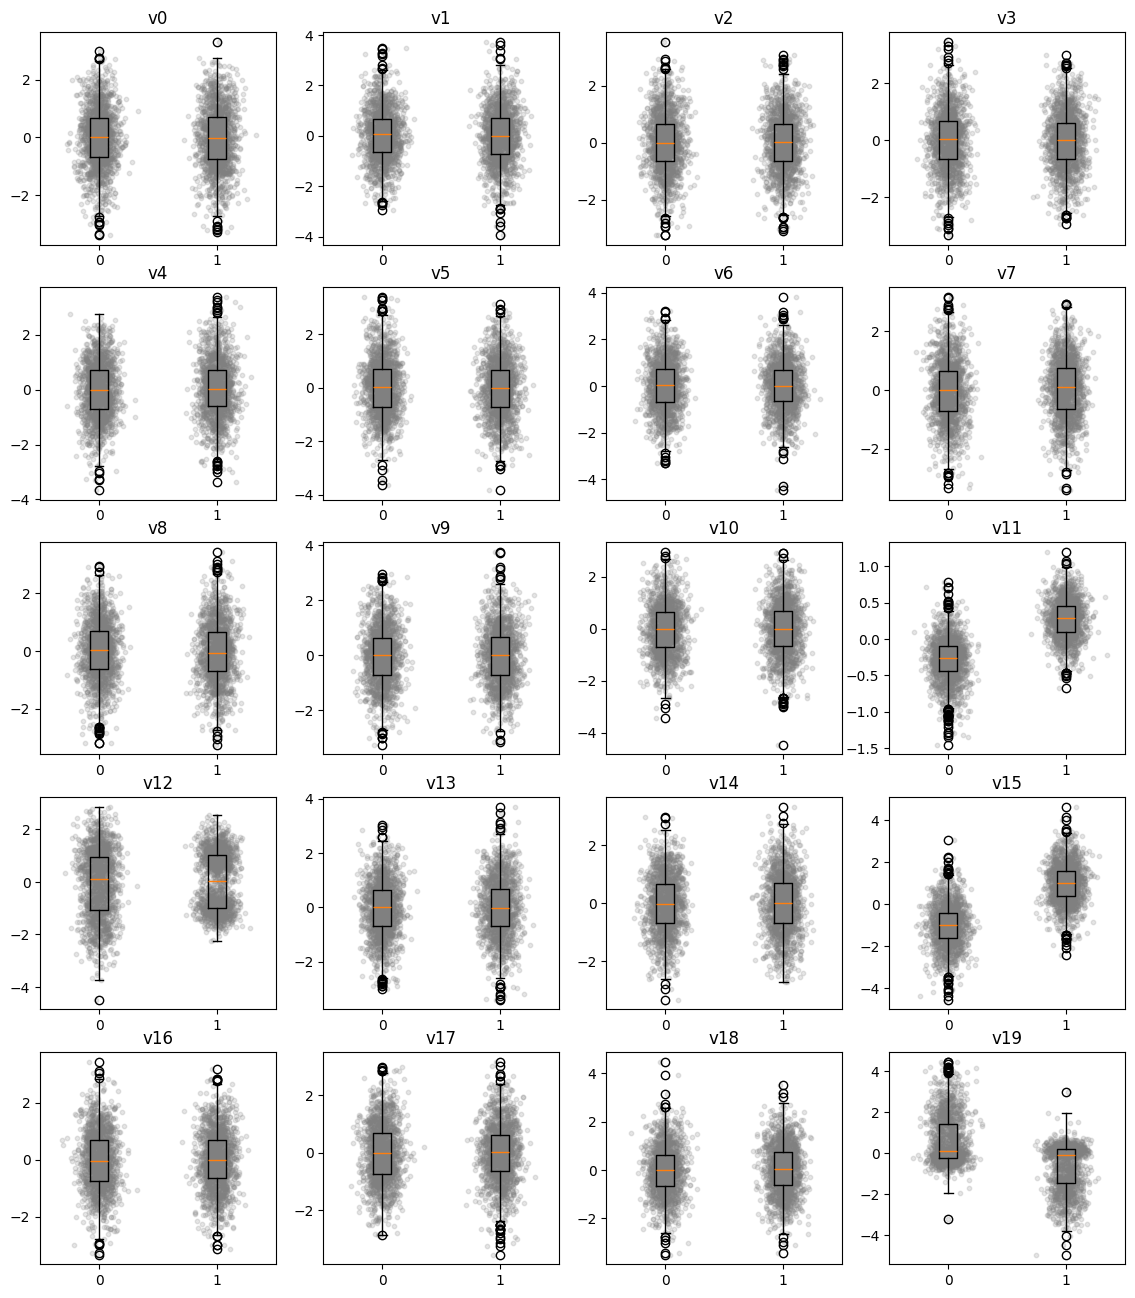

In [5]:
fig, axs = plt.subplots(5, 4, figsize=(14, 16))
axs = axs.flatten()

for feature_idx in range(20):
    x_y0 = X_trainval[y_trainval == 0, feature_idx].numpy()
    x_y1 = X_trainval[y_trainval == 1, feature_idx].numpy()

    x_0 = np.random.normal(1, 0.08, size=len(x_y0))
    x_1 = np.random.normal(2, 0.08, size=len(x_y1))
    axs[feature_idx].scatter(x_0, x_y0, alpha=0.2, color='gray', s=10)
    axs[feature_idx].scatter(x_1, x_y1, alpha=0.2, color='gray', s=10)
    axs[feature_idx].boxplot([x_y0, x_y1], tick_labels=["0", "1"])
    axs[feature_idx].set_title(f"v{feature_idx}")


In [6]:
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(20, 4),
            nn.ReLU(),
            nn.Linear(4, 2),
        )

        self.train_loss_per_epoch = None
        self.val_loss_per_epoch = None

    def forward(self, x):
        x = self.model(x)
        return x

In [7]:
def train_new_model(fold: int, epochs: int, train_loader: DataLoader, val_loader: DataLoader, save_dir: Path|None):
    model = MLP()
    optimizer = torch.optim.Adam(model.parameters())
    loss_fn = CrossEntropyLoss()

    print("Fold: ", fold)

    train_loss_per_epoch = np.zeros(epochs)
    val_loss_per_epoch = np.zeros(epochs)
    best_val_loss = 99999999.9

    for epoch in range(epochs):
        model.train()

        total_train_loss = 0.0
        total_val_loss = 0.0

        for data, target in train_loader:
            optimizer.zero_grad()

            output = model(data)
            loss = loss_fn(output, target)

            total_train_loss += loss.item()

            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            for data, target in val_loader:
                output = model(data)
                loss = loss_fn(output, target)
                total_val_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)
        avg_val_loss = total_val_loss / len(val_loader)
        print(f"{fold=} {epoch=} {avg_train_loss=:.3f} {avg_val_loss=:.3f}")

        train_loss_per_epoch[epoch] = avg_train_loss
        val_loss_per_epoch[epoch] = avg_val_loss

        writer.add_scalar(f"Loss/train/fold{fold}", avg_train_loss, epoch)
        writer.add_scalar(f"Loss/val/fold{fold}", avg_val_loss, epoch)

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss

            if save_dir:
                torch.save(model.state_dict(), save_dir/f"fold{fold}.pth")

    model.train_loss_per_epoch = train_loss_per_epoch
    model.val_loss_per_epoch = val_loss_per_epoch

    return model


In [8]:
def train_models_cv5(epochs: int, save_dir: Path|None) -> nn.ModuleList:
    cv = StratifiedKFold()

    val_losses = 0.0

    models = []

    for fold, (train_idx, val_idx) in enumerate(cv.split(X_trainval, y_trainval)):
        train_loader = DataLoader(Subset(trainval_dataset, train_idx), batch_size=256, shuffle=True)
        val_loader = DataLoader(Subset(trainval_dataset, val_idx), batch_size=256, shuffle=True)
        model = train_new_model(fold, epochs, train_loader, val_loader, save_dir)

        best_val_loss = model.val_loss_per_epoch.min().item()
        val_losses += best_val_loss

        models.append(model)

    return nn.ModuleList(models)

In [9]:
save_dir = Path("checkpoints/best")
save_dir.mkdir(parents=True, exist_ok=True)
models = train_models_cv5(20, save_dir)

Fold:  0
fold=0 epoch=0 avg_train_loss=0.726 avg_val_loss=0.712
fold=0 epoch=1 avg_train_loss=0.711 avg_val_loss=0.702
fold=0 epoch=2 avg_train_loss=0.697 avg_val_loss=0.686
fold=0 epoch=3 avg_train_loss=0.683 avg_val_loss=0.670
fold=0 epoch=4 avg_train_loss=0.671 avg_val_loss=0.660
fold=0 epoch=5 avg_train_loss=0.659 avg_val_loss=0.654
fold=0 epoch=6 avg_train_loss=0.647 avg_val_loss=0.636
fold=0 epoch=7 avg_train_loss=0.634 avg_val_loss=0.628
fold=0 epoch=8 avg_train_loss=0.622 avg_val_loss=0.613
fold=0 epoch=9 avg_train_loss=0.609 avg_val_loss=0.606
fold=0 epoch=10 avg_train_loss=0.595 avg_val_loss=0.585
fold=0 epoch=11 avg_train_loss=0.582 avg_val_loss=0.575
fold=0 epoch=12 avg_train_loss=0.567 avg_val_loss=0.559
fold=0 epoch=13 avg_train_loss=0.552 avg_val_loss=0.543
fold=0 epoch=14 avg_train_loss=0.537 avg_val_loss=0.526
fold=0 epoch=15 avg_train_loss=0.523 avg_val_loss=0.511
fold=0 epoch=16 avg_train_loss=0.508 avg_val_loss=0.496
fold=0 epoch=17 avg_train_loss=0.493 avg_val_loss

In [10]:
class TemperatureScaler(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
        model.eval()
        self.temperature = nn.Parameter(torch.ones(1))

    def forward(self, x):
        logits = self.model(x)
        return logits / self.temperature


In [11]:
def fit_temperature(model: MLP):
    scaler = TemperatureScaler(model)
    optimizer = torch.optim.LBFGS([scaler.temperature], lr=0.001, max_iter=15000)
    criterion = nn.CrossEntropyLoss()

    def closure():
        optimizer.zero_grad()
        logits = scaler(X_cal)
        loss = criterion(logits, y_cal)
        loss.backward()
        return loss

    optimizer.step(closure)
    return scaler


In [12]:
scalers = []
for model in models:
    scaler = fit_temperature(model)
    scalers.append(scaler)
scalers = nn.ModuleList(scalers)

In [13]:
def compute_entropy(probs):
    return -np.sum(probs * np.log2(probs + 1e-12), axis=-1)

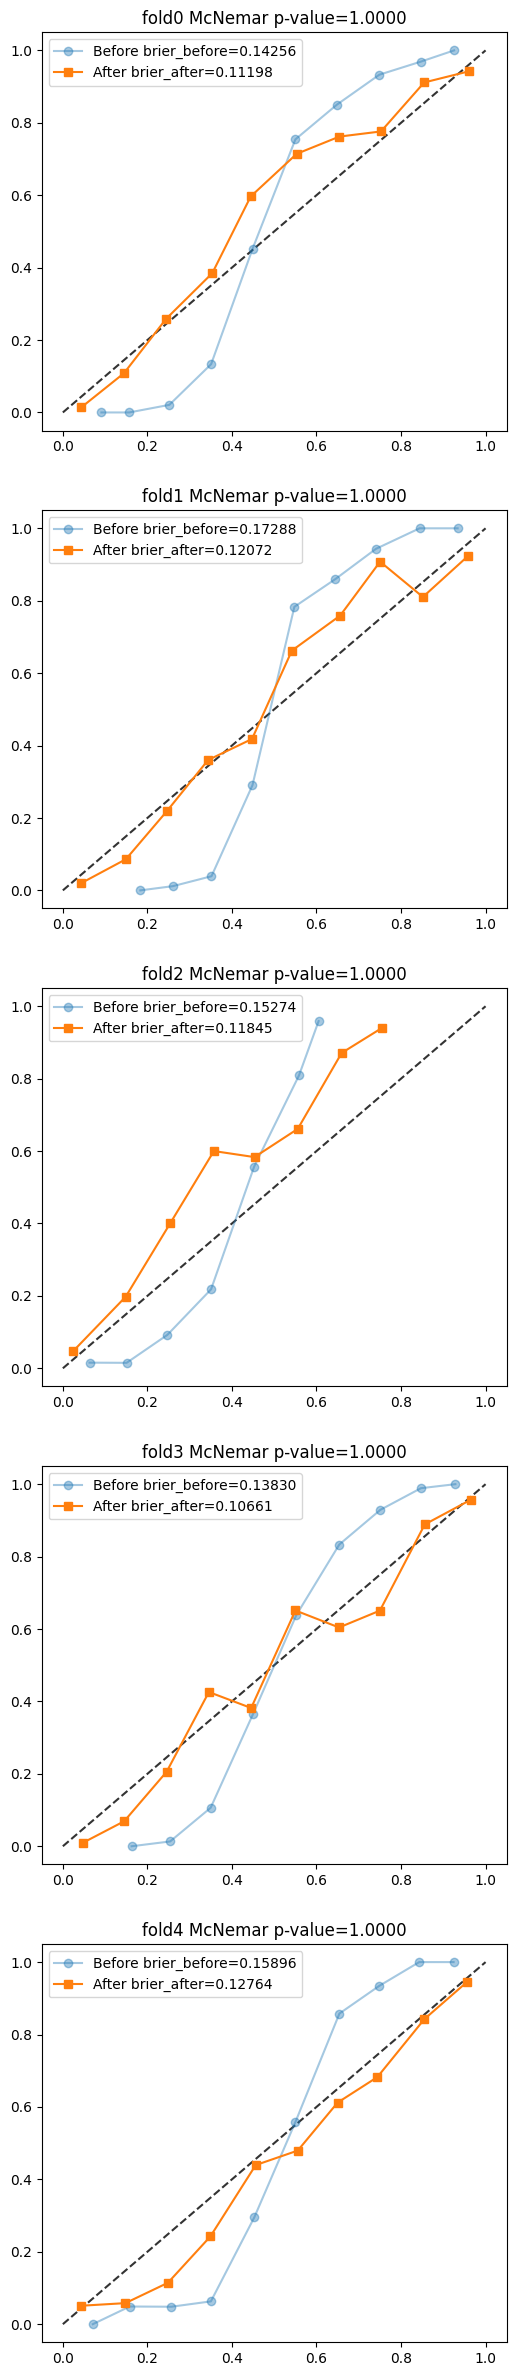

In [14]:
fig, axs = plt.subplots(5, 1, figsize=(6, 5*6))
all_probs_before = []
all_probs_after = []
for fold, (model, scaler) in enumerate(zip(models, scalers)):
    logits = model(X_test).detach()
    probs_before = F.softmax(logits, dim=1).numpy()
    all_probs_before.append(probs_before)
    probs_of_one_before = probs_before[:, 1]

    logits_scaled = scaler(X_test).detach()
    probs_after = F.softmax(logits_scaled, dim=1).numpy()
    all_probs_after.append(probs_after)
    probs_of_one_after = probs_after[:, 1]

    frac_pos_before, mean_pred_before = calibration_curve(
        y_test, probs_of_one_before, n_bins=10
    )
    frac_pos_after, mean_pred_after = calibration_curve(
        y_test, probs_of_one_after, n_bins=10
    )

    brier_before = brier_score_loss(y_test, probs_of_one_before)
    brier_after = brier_score_loss(y_test, probs_of_one_after)

    y_pred_before = np.argmax(probs_before, axis=1)
    y_pred_after = np.argmax(probs_after, axis=1)
    correct_before = (y_pred_before == y_test)
    correct_after = (y_pred_after == y_test)

    a = np.sum(correct_before & correct_after)
    b = np.sum(correct_before & ~correct_after)
    c = np.sum(~correct_before & correct_after)
    d = np.sum(~correct_before & ~correct_after)

    contingency_table = [[a, b],
                         [c, d]]

    result = mcnemar(contingency_table, exact=True)
    p_value = result.pvalue

    ax = axs[fold]
    ax.set_title(f"fold{fold} McNemar p-value={p_value:.4f}")
    ax.plot([0, 1], [0, 1], "k--", alpha=0.8)
    ax.plot(
        mean_pred_before,
        frac_pos_before,
        "o-",
        alpha=0.4,
        label=f"Before {brier_before=:.5f}"
    )
    ax.plot(
        mean_pred_after,
        frac_pos_after,
        "s-",
        label=f"After {brier_after=:.5f}"
    )
    ax.legend()

all_probs_before = np.array(all_probs_before)
all_probs_after = np.array(all_probs_after)

In [15]:
mean_probs_before = np.mean(all_probs_before, axis=0)
mean_probs_after = np.mean(all_probs_after, axis=0)

total_unc_before = compute_entropy(mean_probs_before)
aleatoric_unc_before = np.mean(compute_entropy(all_probs_before), axis=0)
epistemic_unc_before = total_unc_before - aleatoric_unc_before

total_unc_after = compute_entropy(mean_probs_after)
aleatoric_unc_after = np.mean(compute_entropy(all_probs_after), axis=0)
epistemic_unc_after = total_unc_after - aleatoric_unc_after

pd.DataFrame([
    [total_unc_before.mean(), total_unc_after.mean()],
    [aleatoric_unc_before.mean(), aleatoric_unc_after.mean()],
    [epistemic_unc_before.mean(), epistemic_unc_after.mean()],
], index=["total", "aleatoric", "epistemic"], columns=["before", "after"])

,before,after
total,0.903737,0.632326
aleatoric,0.884437,0.573947
epistemic,0.019300,0.058379
